In [ ]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\archive (2)\dirty_cafe_sales.csv")
df

In [ ]:
df.dropna(how="all",inplace=True)
df

In [ ]:
df['Item']=df['Item'].str.title()
df


In [ ]:
df['Location']=df['Location'].str.upper()
df

In [ ]:
df['Transaction ID']=df['Transaction ID'].str.replace("TXN_","")

df['Total Spent']=df['Total Spent'].round(0)
df


In [ ]:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')
df['Total']=df['Price Per Unit']*df['Quantity']
df



In [ ]:
df.columns=df.columns.str.lower()
df=df.replace(["UNKNOWN","ERROR","Unknown","Error"],np.nan)
df['price per unit']=df['price per unit'].fillna(2)
df['payment method']=df['payment method'].fillna(df['payment method'].mode()[0])
df['item']=df['item'].fillna(df['item'].mode()[0])
df['location']=df['location'].fillna(df['location'].mode()[0])
df['quantity']=df['quantity'].fillna(df['quantity'].mode()[0])
df['total spent']=df['total spent'].fillna(df['total spent'].mode()[0])
df['transaction date']=df['transaction date'].fillna(df['transaction date'].mode()[0])
df['total price']=df['quantity']*df['price per unit']





df

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:

df[['quantity','total price']].agg(['sum','mean','max','min'])

In [ ]:
df['item'].unique()

In [ ]:
df['item'].value_counts()

In [ ]:
df['payment method'].value_counts()

In [ ]:
df.groupby(['payment method','location']).size()

In [ ]:
df.groupby(['payment method','location']).sum()

In [151]:

df.groupby(['payment method','location'])['total price'].agg(['sum','max'])

sum   max
payment method location               
Cash           IN-STORE   6404.0  25.0
               TAKEAWAY  14334.5  25.0
Credit Card    IN-STORE   6069.5  25.0
               TAKEAWAY  14568.5  25.0
Digital Wallet IN-STORE  15094.5  25.0
               TAKEAWAY  34110.5  25.0

In [152]:
df.pivot_table(index='payment method',columns='item',values='total price')

item,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea
payment method,,,,,,,,
Cash,9.264493,6.426230,3.261224,8.873431,14.726316,12.624506,12.805085,4.813278
Credit Card,9.426877,6.115702,3.193676,9.029644,14.652330,12.007812,12.150794,5.051724
Digital Wallet,9.132787,6.329897,3.291246,9.161332,15.419521,12.186495,11.980263,4.742695


<Axes: xlabel='item'>

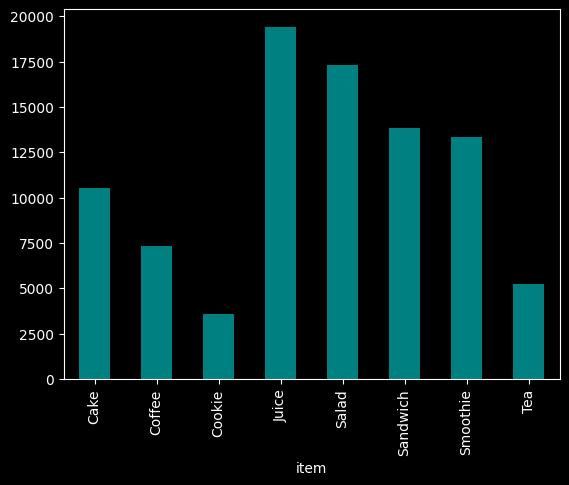

In [153]:
df.groupby('item')['total price'].sum().plot(kind='bar',color='teal')


In [154]:
df

,transaction id,item,quantity,price per unit,total spent,payment method,location,transaction date,total price
0,1961373,Coffee,2.0,2.0,4.0,Credit Card,TAKEAWAY,2023-09-08,4.0
1,4977031,Cake,4.0,3.0,12.0,Cash,IN-STORE,2023-05-16,12.0
2,4271903,Cookie,4.0,1.0,6.0,Credit Card,IN-STORE,2023-07-19,4.0
3,7034554,Salad,2.0,5.0,10.0,Digital Wallet,TAKEAWAY,2023-04-27,10.0
4,3160411,Coffee,2.0,2.0,4.0,Digital Wallet,IN-STORE,2023-06-11,4.0
...,...,...,...,...,...,...,...,...,...
9995,7672686,Coffee,2.0,2.0,4.0,Digital Wallet,TAKEAWAY,2023-08-30,4.0
9996,9659401,Juice,3.0,2.0,3.0,Digital Wallet,TAKEAWAY,2023-06-02,6.0
9997,5255387,Coffee,4.0,2.0,8.0,Digital Wallet,TAKEAWAY,2023-03-02,8.0
9998,7695629,Cookie,3.0,2.0,3.0,Digital Wallet,TAKEAWAY,2023-12-02,6.0


array([<Axes: title={'center': 'total price'}, xlabel='payment method,location'>],
      dtype=object)

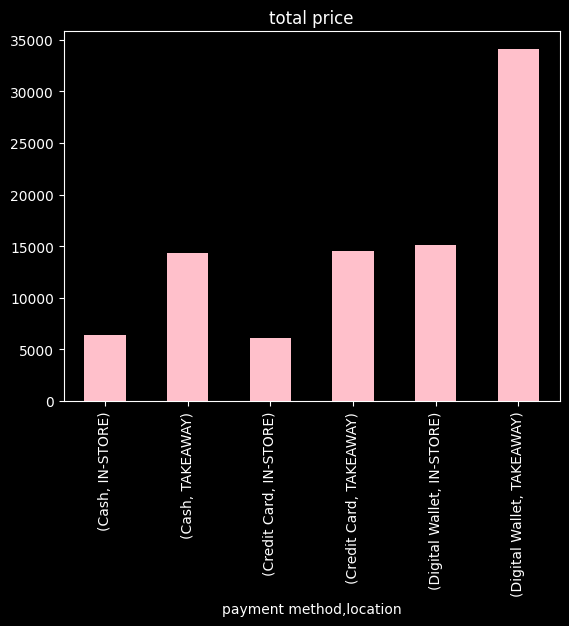

In [155]:
draw=df.groupby(['payment method','location'])['total price'].sum()
draw.plot(kind='bar',color='pink',subplots=True)


<Axes: ylabel='quantity'>

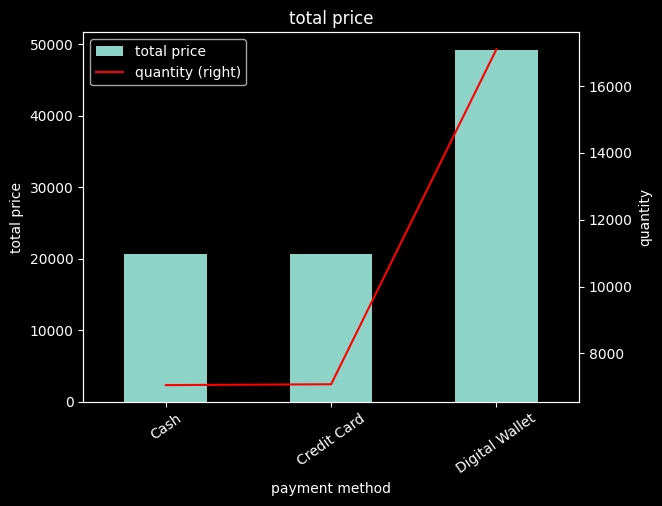

In [156]:
draw=df.groupby('payment method')[['quantity','total price']].sum()
#draw.plot(kind='bar',color='pink',subplots=False)
s1=draw.plot(y='total price',kind='bar',ylabel='total price',title='total price')
draw.plot(y='quantity',kind='line',secondary_y=True,ax=s1,color='red',ylabel='quantity',rot=35)


In [157]:
cat=df['item'].value_counts()
cat

item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

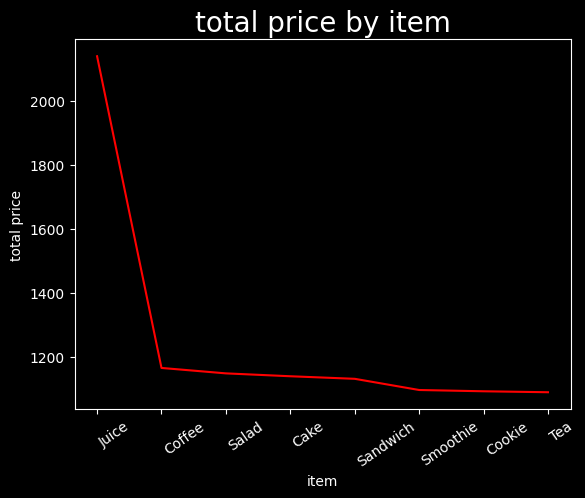

In [158]:
plt.plot(cat,'r')
plt.xticks(rotation=35, ha='left')
plt.ylabel('total price')
plt.xlabel('item')
plt.title('total price by item',fontsize=20)
plt.show()

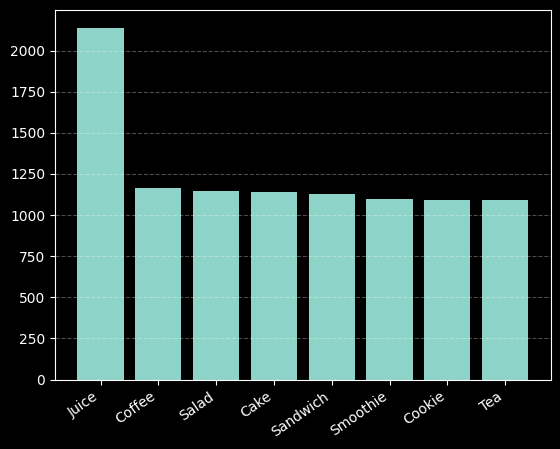

In [159]:
plt.bar(cat.index,cat.values)
plt.grid(axis='y',alpha=0.3,linestyle='--')
plt.xticks(rotation=35, ha='right')
plt.xticks(rotation=35, ha='right')
plt.show()


In [160]:
pie=df['payment method'].value_counts()
pie

payment method
Digital Wallet    5469
Credit Card       2273
Cash              2258
Name: count, dtype: int64

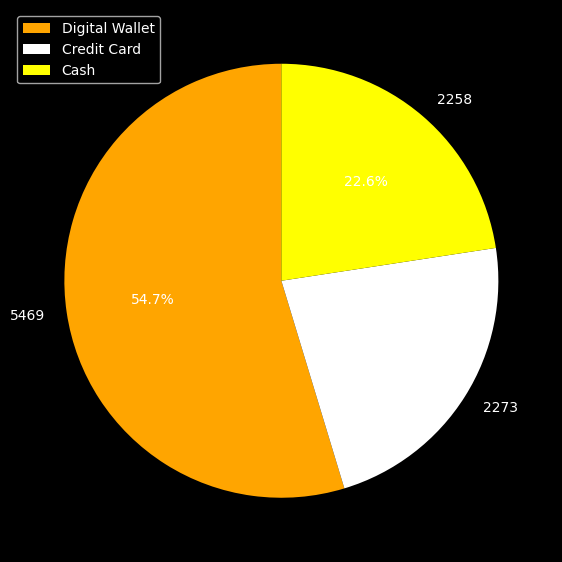

In [161]:
plt.figure(figsize=(7,9))
plt.pie(pie,startangle=90,labels=pie,autopct='%1.1f%%',colors=['orange','w','yellow'])

plt.legend(labels=pie.index,loc='upper left')
plt.show()


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction id    10000 non-null  str    
 1   item              10000 non-null  str    
 2   quantity          10000 non-null  float64
 3   price per unit    10000 non-null  float64
 4   total spent       10000 non-null  str    
 5   payment method    10000 non-null  str    
 6   location          10000 non-null  str    
 7   transaction date  10000 non-null  str    
 8   total price       10000 non-null  float64
dtypes: float64(3), str(6)
memory usage: 703.3 KB


In [174]:
del df['total']
df.info()





KeyError: 'total'

In [ ]:
sns.histplot(data=df,x='item',kde=True,palette='mako',hue='item',legend=False)
plt.show()

In [ ]:

sns.barplot(x='item',y='total price',data=df,palette='muted',hue='item',estimator=np.sum)
plt.xticks(rotation=35)
plt.show()
plt.show()

In [ ]:
sns.scatterplot(data=df,y='total price',x='quantity',palette='muted')
plt.show()

In [ ]:
df

In [ ]:
sns.boxplot(data=df,x='item',y='quantity',palette='crest',hue='item')

In [ ]:
my=df.groupby(['item','payment method','location'],as_index=False)['total price',].sum()
my

In [ ]:
sns.stripplot(x='item',y='total price',hue='item',palette='muted',data=my)

In [ ]:
sns.pairplot(my,hue='item')

In [176]:
df.to_csv('total sales.csv')